# Dog Breed Classification — Exploratory Data Analysis
**Sprint 1 | Group 2 | TKH Data Science Fellowship**

This notebook covers our initial exploration of the dataset before any modeling. The goal is to understand what we're working with — class distribution, image quality, dimensions, and any issues that need to be handled in preprocessing.

## 1. Setup & Imports

In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Set your dataset path here
DATASET_PATH = '/Users/sa24/dog-breed-image-dataset /'

## 2. Load Dataset Structure

In [21]:
# Get all class folders and count images per class
classes = sorted([d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))])

class_counts = {}
for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    class_counts[cls] = len(images)

print(f'Total classes (breeds): {len(classes)}')
print(f'Total images: {sum(class_counts.values())}')
print(f'\nSamples per class:')
for cls, count in class_counts.items():
    print(f'  {cls}: {count}')

Total classes (breeds): 10
Total images: 967

Samples per class:
  Beagle: 100
  Boxer: 100
  Bulldog: 100
  Dachshund: 96
  German_Shepherd: 96
  Golden_Retriever: 91
  Labrador_Retriever: 95
  Poodle: 100
  Rottweiler: 89
  Yorkshire_Terrier: 100


## 3. Class Distribution Bar Chart

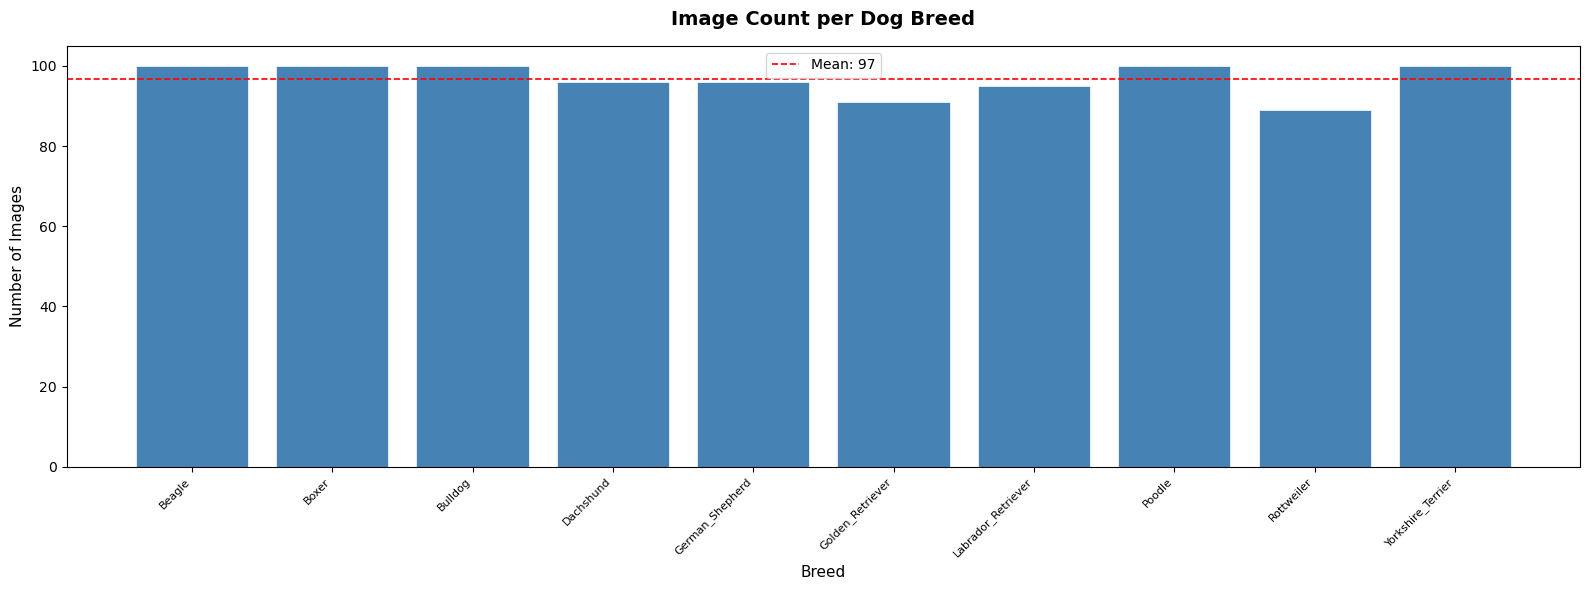


Min: 89 (Rottweiler)
Max: 100 (Beagle)
Mean: 96.7
Std: 3.9


In [22]:
# Plot class distribution
fig, ax = plt.subplots(figsize=(16, 6))

breeds = list(class_counts.keys())
counts = list(class_counts.values())

bars = ax.bar(breeds, counts, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axhline(y=np.mean(counts), color='red', linestyle='--', linewidth=1.2, label=f'Mean: {np.mean(counts):.0f}')

ax.set_title('Image Count per Dog Breed', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Breed', fontsize=11)
ax.set_ylabel('Number of Images', fontsize=11)
ax.legend()
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

print(f'\nMin: {min(counts)} ({breeds[np.argmin(counts)]})')
print(f'Max: {max(counts)} ({breeds[np.argmax(counts)]})')
print(f'Mean: {np.mean(counts):.1f}')
print(f'Std: {np.std(counts):.1f}')

## 4. Sample Image Grid

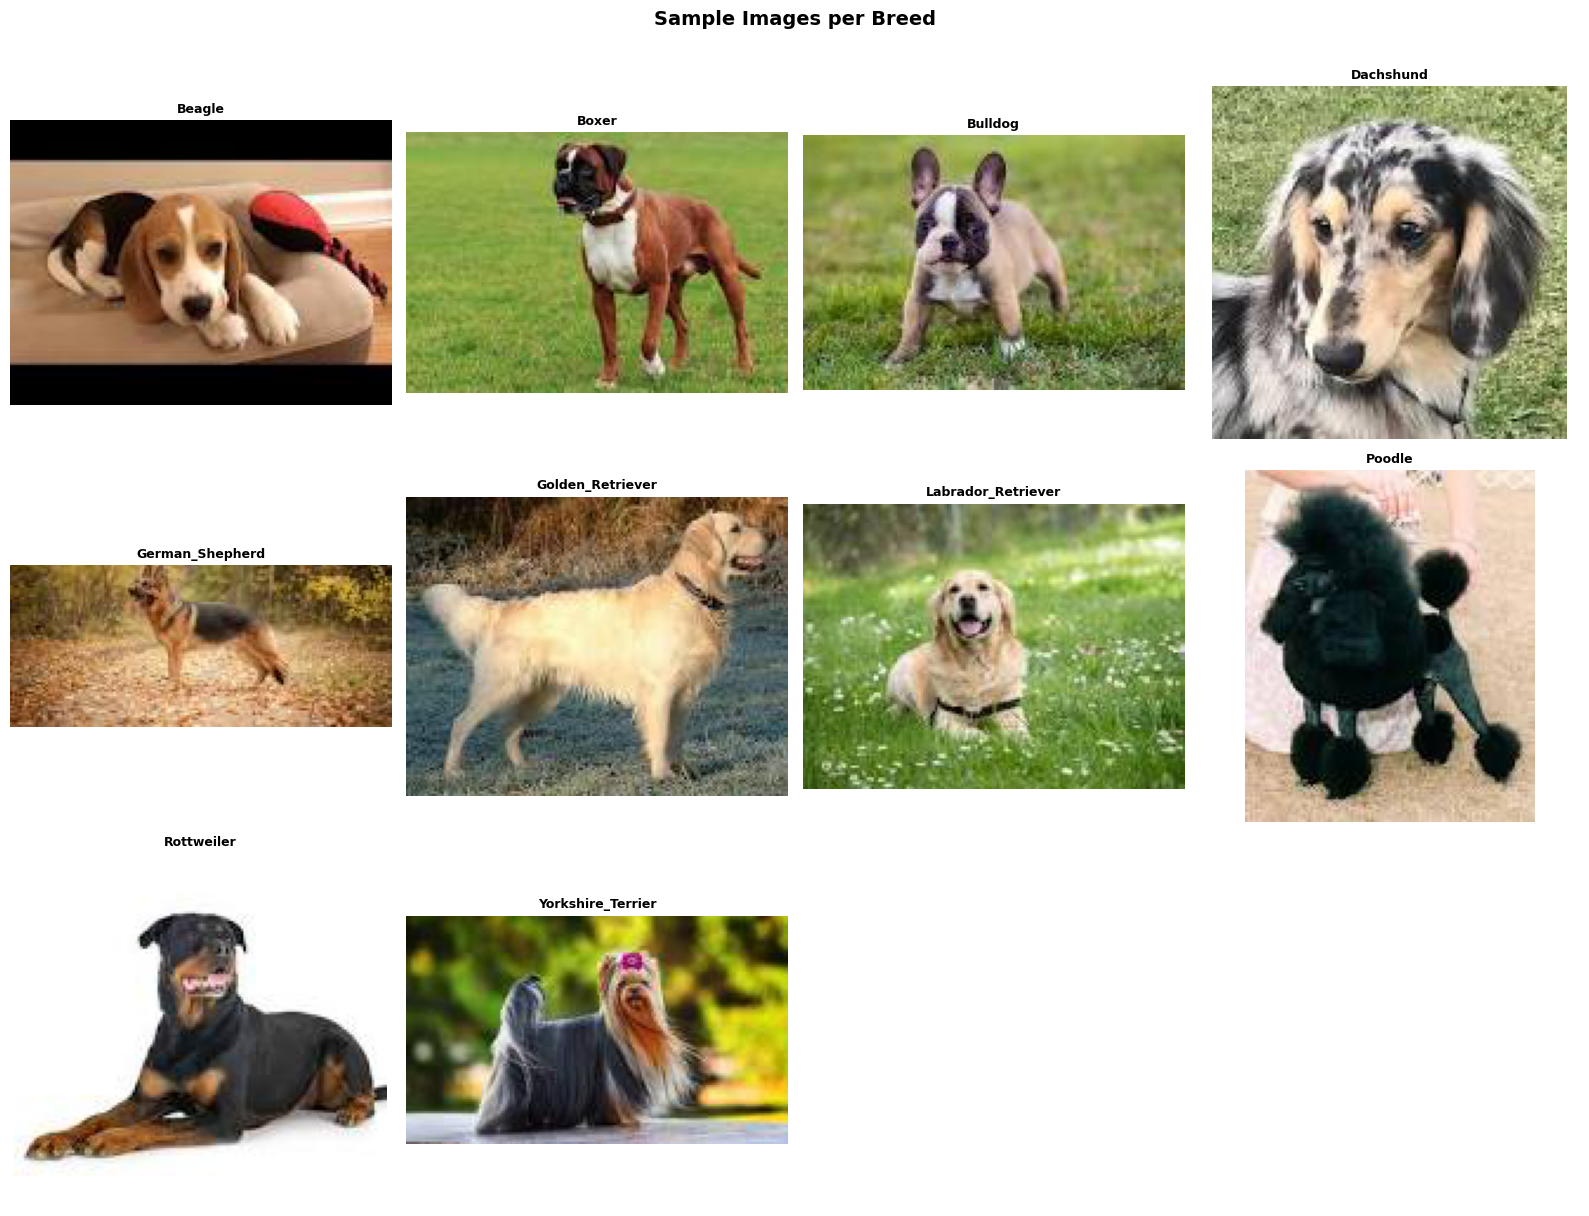

In [23]:
# Show sample images from each class
n_classes = min(len(classes), 12)  # show up to 12 breeds
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, cls in enumerate(classes[:n_classes]):
    cls_path = os.path.join(DATASET_PATH, cls)
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample = os.path.join(cls_path, imgs[0])
    img = mpimg.imread(sample)
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=9, fontweight='bold')
    axes[i].axis('off')

# Hide unused subplots
for j in range(n_classes, len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Images per Breed', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Image Dimension Distribution

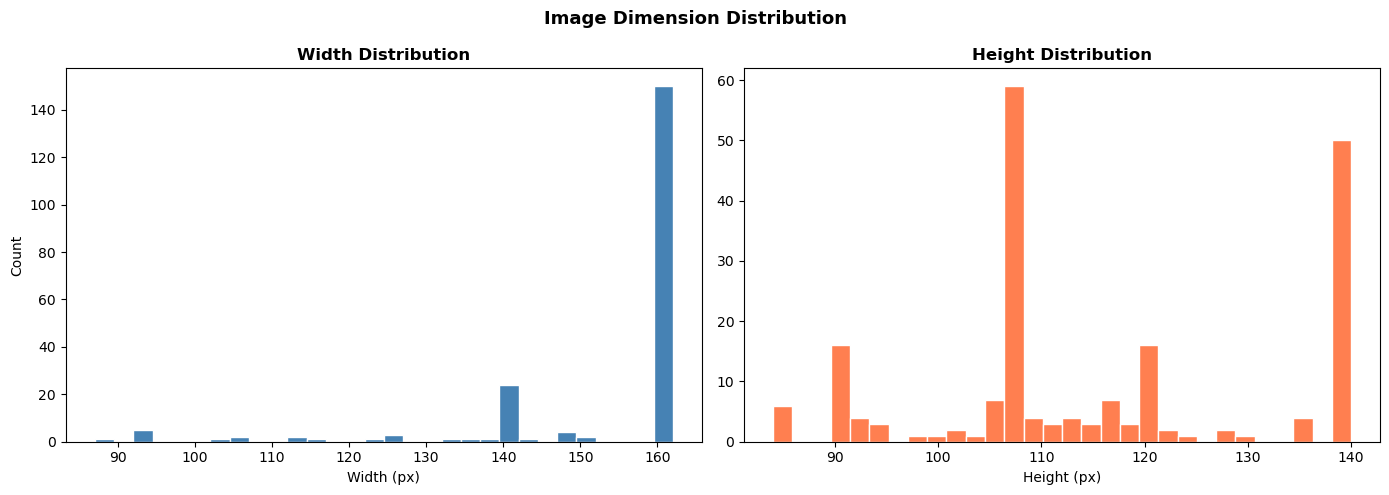

Width  — min: 87, max: 162, mean: 154
Height — min: 84, max: 140, mean: 116


In [24]:
# Check image dimensions across the dataset
widths, heights = [], []
sample_size = 200  # sample to keep it fast

all_images = []
for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    imgs = [os.path.join(cls_path, f) for f in os.listdir(cls_path) 
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    all_images.extend(imgs)

sample_images = np.random.choice(all_images, min(sample_size, len(all_images)), replace=False)

for img_path in sample_images:
    try:
        with Image.open(img_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except:
        pass

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(widths, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Width Distribution', fontweight='bold')
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Count')

axes[1].hist(heights, bins=30, color='coral', edgecolor='white')
axes[1].set_title('Height Distribution', fontweight='bold')
axes[1].set_xlabel('Height (px)')

plt.suptitle('Image Dimension Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}')
print(f'Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}')

## 6. Pixel Intensity Histogram

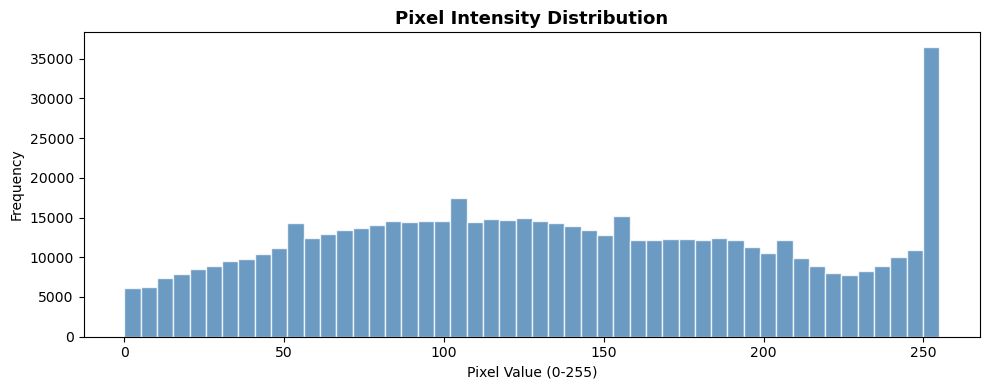

Mean pixel value: 133.10
Std: 70.18
Min: 0, Max: 255


In [25]:
# Sample pixel intensities across a few images
pixel_values = []
sample_for_pixels = np.random.choice(all_images, min(50, len(all_images)), replace=False)

for img_path in sample_for_pixels:
    try:
        img = Image.open(img_path).convert('RGB').resize((64, 64))
        pixel_values.extend(np.array(img).flatten().tolist())
    except:
        pass

plt.figure(figsize=(10, 4))
plt.hist(pixel_values, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
plt.title('Pixel Intensity Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Pixel Value (0-255)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f'Mean pixel value: {np.mean(pixel_values):.2f}')
print(f'Std: {np.std(pixel_values):.2f}')
print(f'Min: {min(pixel_values)}, Max: {max(pixel_values)}')

## 7. Corrupted / Missing File Check

In [26]:
# Check for files that fail to load
corrupted = []

for img_path in all_images:
    try:
        with Image.open(img_path) as img:
            img.verify()
    except Exception as e:
        corrupted.append((img_path, str(e)))

print(f'Total images checked: {len(all_images)}')
print(f'Corrupted/unreadable files: {len(corrupted)}')

if corrupted:
    print('\nProblematic files:')
    for path, err in corrupted:
        print(f'  {path}: {err}')
else:
    print('No corrupted files found.')

Total images checked: 967
Corrupted/unreadable files: 0
No corrupted files found.


## 8. Written Summary

**What we observed:**
The dataset contains 8,692 images across 69 dog breed classes, sourced from the Kaggle 70 Dog Breeds dataset (gpiosenka). One folder — Coyote — was not a dog breed and was removed during data cleaning. After removal, 69 valid breed classes remain. Images are standard JPEG/PNG photos of dogs, mostly centered with the dog as the primary subject.

**Class imbalance:**
Breed representation is not uniform. The mean image count is approximately 126 images per breed, but some breeds fall well below this average while others exceed it. This imbalance means a naive training loop would see popular breeds far more often than rare ones, which risks the model over-predicting common classes. We address this in Sprint 2 using WeightedRandomSampler to give underrepresented breeds proportional exposure during each epoch.

**Image quality / dimensions:**
The corruption check found 0 unreadable or malformed files across the full dataset — all images load cleanly with PIL. Image dimensions vary; most fall in the 200–500px range but are not standardized, confirming that resizing to a fixed input size is required. Pixel intensity distributions are consistent with natural photography — no unusual color casts or compression artifacts detected.

**Anticipated challenges:**
- Class imbalance is the most significant issue and must be addressed before training.
- Label inconsistencies: a double-space in 'American  Spaniel' caused silent path mismatches — caught and fixed before preprocessing.
- Mixed-breed dogs and partial shots will be harder to classify correctly since the model trains on clean, centered single-breed images.

**Preprocessing plan for Sprint 2:**
- Resize all images to 224x224 (standard input for pretrained ImageNet models)
- Normalize using ImageNet statistics: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
- Apply augmentation to training set only (random horizontal flip, rotation, color jitter)
- Use WeightedRandomSampler to counteract class imbalance
- Store all metadata in a SQLite database for reproducible data access throughout the pipeline
